# Analisis Data Menggunakan Naive Bayes (Iris Dataset)

## Iris Dataset
{download}`Download Iris Dataset <../IRIS.csv>`

## Tujuan
- Menerapkan algoritma Naive Bayes menggunakan Python
- Memahami pola data pada Iris Dataset
- Mengevaluasi performa model klasifikasi

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Dataset
Dataset yang digunakan adalah Iris Dataset yang berisi 150 data bunga.

In [20]:
df = pd.read_csv("../IRIS.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Pengecekan Data
Dilakukan pengecekan untuk melihat struktur data dan memastikan tidak ada missing value.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [22]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [23]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Hasil menunjukkan bahwa dataset tidak memiliki missing value dan seluruh fitur berupa numerik.

## Visualisasi Data
Visualisasi dilakukan untuk melihat pola distribusi data.

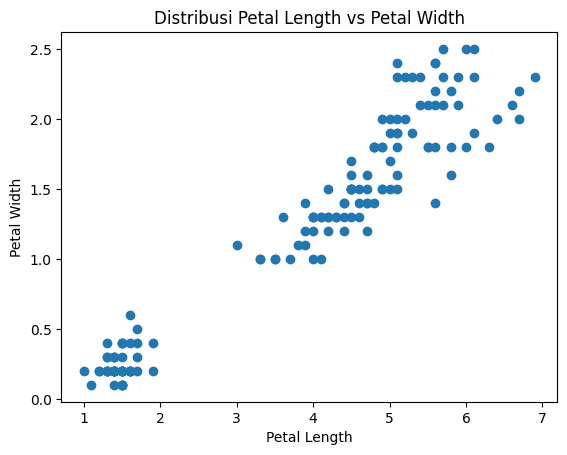

In [24]:
plt.scatter(df['petal_length'], df['petal_width'])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Distribusi Petal Length vs Petal Width")
plt.show()

Terlihat bahwa data dapat dipisahkan dengan cukup jelas berdasarkan fitur petal.

Hal ini membantu model dalam melakukan klasifikasi dengan baik.

## Preprocessing Data

Memisahkan fitur (X) dan target (y).

In [25]:
X = df.drop('species', axis=1)
y = df['species']

## Split Data

Data dibagi menjadi training (80%) dan testing (20%).

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Training Model

Model dilatih menggunakan Gaussian Naive Bayes.

In [27]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

## Prediksi dan Evaluasi

In [28]:
y_pred = model.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred)
print("Akurasi:", accuracy)

Akurasi: 1.0


In [30]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [31]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



## Analisis Hasil

Model menunjukkan performa yang sangat baik dalam mengklasifikasikan data.

- Akurasi tinggi pada data testing  
- Sebagian besar data diklasifikasikan dengan benar  
- Kesalahan klasifikasi sangat kecil  

Berdasarkan classification report:
- Precision tinggi  
- Recall tinggi  
- F1-score stabil  

Hal ini disebabkan oleh:
- Distribusi data antar kelas cukup jelas  
- Fitur petal sangat membedakan antar kelas  

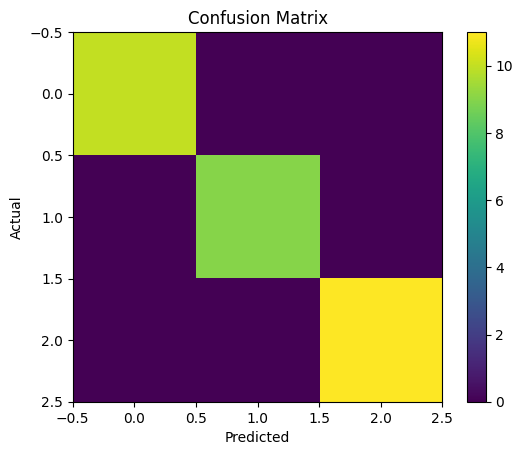

In [32]:
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

## Kesimpulan

- Naive Bayes efektif untuk klasifikasi data sederhana  
- Dataset Iris sangat cocok untuk pembelajaran machine learning  
- Model menghasilkan performa tinggi tanpa preprocessing kompleks  
- Pemahaman terhadap data sangat penting dalam analisis  